In [2]:
import scipy

scipy.stats.distributions.poisson.pmf(5, 4.5)

0.17082685848611215

# 1/10   Введение

## Задание 1.10

В интернет-магазине среднее время между покупками одного пользователя составляет $5$ дней. Если пользователь не сделал покупку за первые $7$ дней, какова вероятность того, что он сделает покупку в течение последующих $3$ дней? Ответ округлите до трех знаков после разделителя.

In [3]:
import math

def get_factorial(number):
    if number <= 1:
        return 1
    else:
        return get_factorial(number - 1) * number

In [4]:
lambda_value = 1 / 5
days = 3
p_days = lambda_value ** days / get_factorial(days) * math.exp(-lambda_value)
1 - p_days

0.998908358995896

In [5]:
import math

# Параметры
mean_time = 5  # среднее время между покупками в днях
lambda_param = 1 / mean_time  # параметр экспоненциального распределения

# Время, за которое нужно найти вероятность (после 7 дней без покупок)
t = 3

# Вероятность P(T <= 3) для экспоненциального распределения
probability = 1 - math.exp(-lambda_param * t)

print(f"Среднее время между покупками: {mean_time} дней")
print(f"Параметр λ: {lambda_param:.3f}")
print(f"Вероятность покупки в течение {t} дней: {probability:.6f}")
print(f"Ответ (округлено до 3 знаков): {probability:.3f}")

Среднее время между покупками: 5 дней
Параметр λ: 0.200
Вероятность покупки в течение 3 дней: 0.451188
Ответ (округлено до 3 знаков): 0.451


In [6]:
# Альтернативная версия с использованием scipy
from scipy.stats import expon

# Параметры (в scipy scale = 1/λ = mean)
probability_scipy = expon.cdf(t, scale=mean_time)

print(f"Проверка через scipy: {probability_scipy:.6f}")
print(f"Округлённый ответ: {probability_scipy:.3f}")

Проверка через scipy: 0.451188
Округлённый ответ: 0.451


# 3/10   Основные распределения случайных величин

## Дискретное равномерное распределение

$M\xi = \frac{a_1 + a_2 + … + a_n}{n}\Leftrightarrow \frac{n+1}{2}$

$D\xi = \frac{(a_1 - M\xi)^2 + \dots + (a_n - M\xi)^2}{n}\Leftrightarrow \frac{n^2-1}{12}$

## Ширина пика на половине высоты (FWHM)

В случае нормального распределения, определяемого выражением:

$f(x) = \frac{1}{\sigma \sqrt{2 \pi} } \exp \left[ -\frac{(x-x_0)^2}{2 \sigma^2} \right]\,$

где $\sigma$ — стандартное отклонение, $x_0$ — медиана, высота максимума равна $\frac{1}{\sigma \sqrt{2 \pi} },$ а полуширина выражается через стандартное отклонение следующим образом:

$\mathrm{FWHM} =   2 \sqrt{2 \ln 2 } \; \sigma \approx 2{,}355 \; \sigma$.

(array([0.11984801, 0.23969601, 0.31160482, 0.67114884, 0.93481446,
        1.39023688, 1.51008489, 2.13329453, 2.27711214, 2.51680815,
        2.25314254, 2.08535533, 1.89359852, 1.41420649, 1.27038888,
        0.69511844, 0.64717924, 0.50336163, 0.26366562, 0.43145283,
        0.16778721, 0.09587841, 0.0239696 , 0.0479392 , 0.0479392 ,
        0.        , 0.        , 0.        , 0.        , 0.0239696 ]),
 array([0.56340961, 0.60512912, 0.64684863, 0.68856814, 0.73028765,
        0.77200716, 0.81372666, 0.85544617, 0.89716568, 0.93888519,
        0.9806047 , 1.02232421, 1.06404372, 1.10576323, 1.14748274,
        1.18920224, 1.23092175, 1.27264126, 1.31436077, 1.35608028,
        1.39779979, 1.4395193 , 1.48123881, 1.52295831, 1.56467782,
        1.60639733, 1.64811684, 1.68983635, 1.73155586, 1.77327537,
        1.81499488]),
 <BarContainer object of 30 artists>)

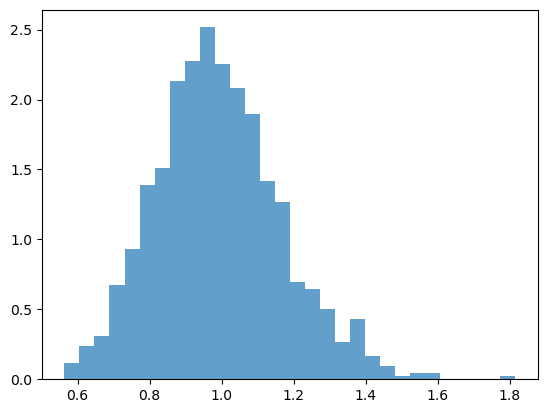

In [7]:
# Пример: Эмпирическая проверка ЦПТ
import numpy as np
import matplotlib.pyplot as plt
means = [np.mean(np.random.exponential(scale=1.0, size=30)) for _ in range(1000)]
plt.hist(means, bins=30, density=True, alpha=0.7)
# Наложить нормальную кривую с параметрами, предсказанными ЦПТ

In [8]:
import numpy as np
from scipy.stats import norm

# Параметры распределения
mu = 4
sigma = 1
threshold = 4.5

# Z-оценка
z = (threshold - mu) / sigma

# Вероятность P(Z > z)
prob = 1 - norm.cdf(z)

# Процент студентов
percent = prob * 100

# Округление до двух знаков после запятой
percent_rounded = round(percent, 2)

print(f"Z-оценка для балла {threshold}: {z:.2f}")
print(f"Вероятность балла > {threshold}: {prob:.5f}")
print(f"Процент студентов с баллом > {threshold}: {percent_rounded:.2f}%")

Z-оценка для балла 4.5: 0.50
Вероятность балла > 4.5: 0.30854
Процент студентов с баллом > 4.5: 30.85%
